Saved executed Colab notebook imported on 2026-09-04. Existing outputs are the original run, not a new training run. Its test accuracy (0.9971145919) and test size (2426) match the imported intent report. Local runtime uses this exported TF-IDF/LinearSVC model.

# 03 — Classical intent classification
**Goal:** compare word TF-IDF + Logistic Regression with word TF-IDF + Linear SVM. Select on validation macro-F1, evaluate once on test data, export the complete pipeline.

Run in VS Code using the project's `.venv` Python kernel. Colab CPU also works. No API key, GPU or model download is needed. The first data cell downloads the public Bitext CSV. Run in order; pause after the comparison if you want to discuss validation results before final testing.

This delivered notebook is unexecuted. Offline fixture checks verify code behavior, not model accuracy. Your real metrics appear when you run it.

TF-IDF converts words and two-word phrases into numeric features. Logistic Regression and Linear SVM learn different decision rules on those features. Intent means what the customer wants, not how they feel.


## 1. Dependencies
The project already has these packages. Only run the installation command below if an import fails. It is commented out so Run All does not modify a working environment. Use scikit-learn 1.6.1 to match your language model; restart the kernel after installation.


In [1]:
# Optional, only if needed:
# import subprocess, sys
# subprocess.check_call([sys.executable, '-m', 'pip', 'install',
#     'scikit-learn==1.6.1', 'numpy', 'pandas', 'matplotlib', 'joblib', 'certifi'])
import sys, json, re, ssl, urllib.request, hashlib, time, warnings, shutil, unicodedata
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import certifi, joblib
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.exceptions import ConvergenceWarning

SEED = 42
BASE = Path.cwd() / 'intent_classical_work'
RUN = BASE / 'runs' / datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S-%f')
REPORTS = RUN / 'reports'
REPORTS.mkdir(parents=True, exist_ok=True)
print('Python:', sys.version.split()[0], '| scikit-learn:', version('scikit-learn'))
print('Run directory:', RUN)


Python: 3.13.15 | scikit-learn: 1.6.1
Run directory: /content/intent_classical_work/runs/20260903-095023-687516


## 2. Download the pinned dataset and define the complete routing map
Input = `instruction`; target = `intent`. The dataset's agent `response`, intent name, category and generation flags are never input features. Responses are reserved for the later RAG module.

All 27 labels map to a route. Complaint/review is flagged for priority as requested in the brief; human-contact requests have their own handoff route. Newsletter preferences are grouped with account management. These are routing signals, not completed real-world actions.


In [2]:
GROUPS = {
    'order_status': ['track_order', 'delivery_options', 'delivery_period'],
    'order_management': ['cancel_order', 'change_order', 'place_order',
                         'change_shipping_address', 'set_up_shipping_address'],
    'billing_and_refunds': ['check_invoice', 'get_invoice', 'get_refund', 'track_refund',
                           'check_refund_policy', 'payment_issue', 'check_payment_methods', 'check_cancellation_fee'],
    'account_management': ['create_account', 'edit_account', 'delete_account', 'switch_account',
                           'recover_password', 'registration_problems', 'newsletter_subscription'],
    'complaint': ['complaint', 'review'],
    'human_handoff': ['contact_customer_service', 'contact_human_agent'],
}
ROUTES = {intent:group for group,intents in GROUPS.items() for intent in intents}
LABELS = sorted(ROUTES)
assert len(LABELS) == 27
REVISION = 'fb86d1b60038970d79fefbfa0c28b47c22d8b961'
URL = ('https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset/resolve/'
       + REVISION + '/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv')
DATA_PATH = BASE / 'data' / 'bitext.csv'
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
if not DATA_PATH.exists():
    with urllib.request.urlopen(URL, context=ssl.create_default_context(cafile=certifi.where()), timeout=60) as response:
        content = response.read()
    # Validate before caching so a failed/HTML download is not retained as data.
    import io
    preview = pd.read_csv(io.BytesIO(content))
    if not {'instruction','intent'}.issubset(preview.columns):
        raise ValueError('Download is not the expected dataset CSV.')
    DATA_PATH.write_bytes(content)
raw = pd.read_csv(DATA_PATH)
assert {'instruction','intent'}.issubset(raw.columns)
assert set(raw.intent.dropna()) == set(LABELS), 'Unexpected labels: inspect the dataset.'
DATA_SHA256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print('Raw rows:',len(raw), '| intent labels:',raw.intent.nunique())
display(raw[['instruction','intent']].head())
display(pd.DataFrame([{'intent':k,'route':v} for k,v in ROUTES.items()]))


Raw rows: 26872 | intent labels: 27


,instruction,intent
0,question about cancelling order {{Order Number}},cancel_order
1,i have a question about cancelling oorder {{Or...,cancel_order
2,i need help cancelling puchase {{Order Number}},cancel_order
3,I need to cancel purchase {{Order Number}},cancel_order
4,"I cannot afford this order, cancel purchase {{...",cancel_order


,intent,route
0,track_order,order_status
1,delivery_options,order_status
2,delivery_period,order_status
3,cancel_order,order_management
4,change_order,order_management
5,place_order,order_management
6,change_shipping_address,order_management
7,set_up_shipping_address,order_management
8,check_invoice,billing_and_refunds
9,get_invoice,billing_and_refunds


## 3. Audit duplicates and split related templates together
Remove blank rows, conflicting exact normalized labels, and exact duplicates. A grouping key also ignores punctuation and normalizes placeholders/numbers. Related examples with the same key stay together across splits.

Use ten stratified group folds: eight for training, one validation, one test (approximately 80/10/10). Stratification tries to preserve label proportions; groups make exact proportions approximate. This avoids selected forms of leakage, but does not remove all paraphrases or generated-template overlap. Keep this limitation in your report.

Grouping is an audit rule, not learned model preprocessing. The TF-IDF vocabulary and IDF weights are fitted on training text only.


{
  "raw_rows": 26872,
  "retained_rows": 24274,
  "conflicting_rows": 0,
  "exact_duplicate_rows": 2598,
  "split_sizes": {
    "train": 19430,
    "validation": 2418,
    "test": 2426
  },
  "template_groups": 23621,
  "source_url": "https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset/resolve/fb86d1b60038970d79fefbfa0c28b47c22d8b961/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv",
  "sha256": "6f81102b0100b97b8468eb04368033a23206bf1fde9d53500d5806ec1001a434"
}


split,test,train,validation
intent,,,
cancel_order,40,352,44
change_order,80,696,80
change_shipping_address,98,763,100
check_cancellation_fee,79,763,99
check_invoice,97,723,93
check_payment_methods,107,800,86
check_refund_policy,102,773,99
complaint,95,807,95
contact_customer_service,102,783,102


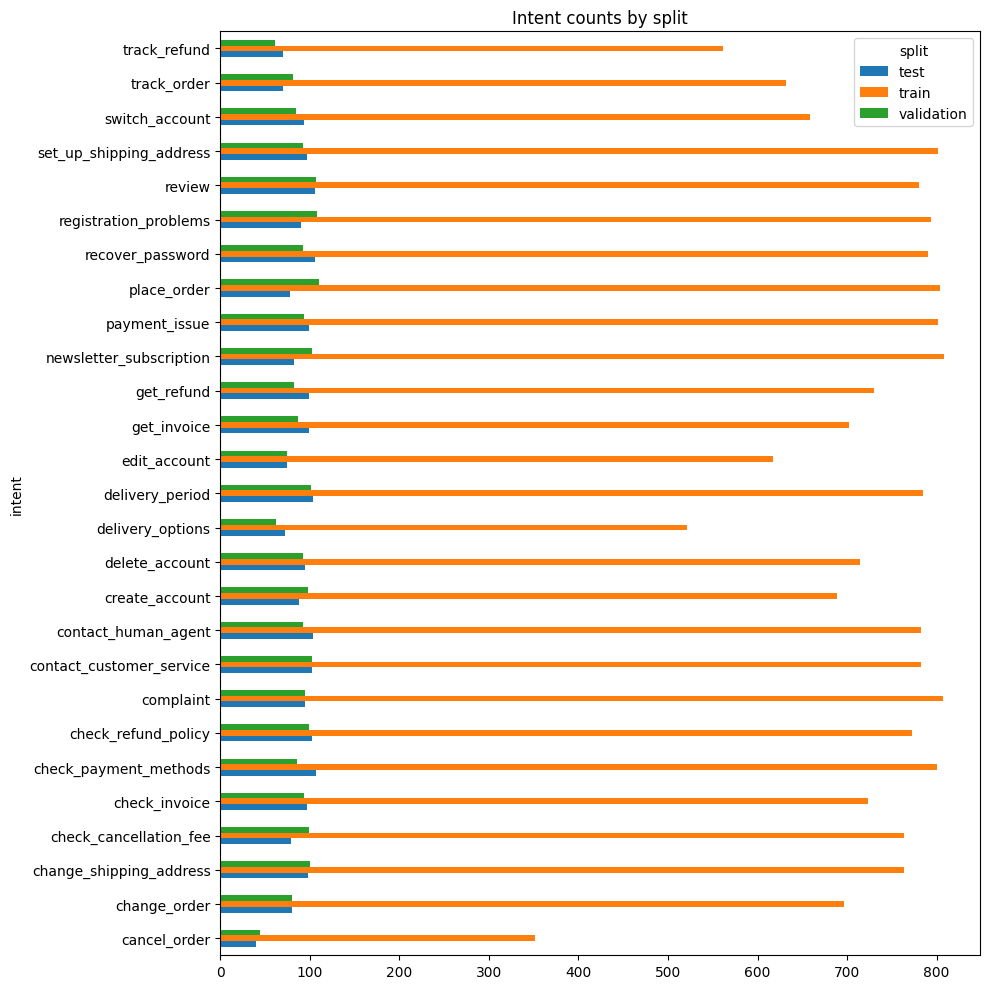

In [3]:
def exact_key(text):
    return ' '.join(unicodedata.normalize('NFC', str(text)).casefold().split())

def template_key(text):
    text = re.sub(r'\{\{.*?\}\}', ' placeholder ', exact_key(text))
    text = re.sub(r'\d+', ' number ', text)
    return ' '.join(re.sub(r'[^\w\s]', ' ', text).split())

frame = raw[['instruction','intent']].dropna().copy()
frame['key'] = frame.instruction.map(exact_key)
frame = frame[frame.key != ''].copy()
conflicts = frame.groupby('key').intent.nunique()
conflicting_keys = set(conflicts[conflicts > 1].index)
conflicting_rows = int(frame.key.isin(conflicting_keys).sum())
frame = frame[~frame.key.isin(conflicting_keys)].copy()
duplicate_rows = int(frame.duplicated('key').sum())
frame = frame.drop_duplicates('key').reset_index(drop=True)
frame['group'] = frame.instruction.map(template_key)
assert set(frame.intent) == set(LABELS)
assert (frame.groupby('intent').group.nunique() >= 10).all(), 'Too few independent groups for ten folds.'
folds = np.full(len(frame), -1)
cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED)
for fold, (_, indices) in enumerate(cv.split(frame.instruction, frame.intent, frame.group)):
    folds[indices] = fold
frame['split'] = np.where(folds == 0, 'test', np.where(folds == 1, 'validation', 'train'))
splits = {name:frame[frame.split == name].copy() for name in ['train','validation','test']}
for name, split in splits.items():
    assert set(split.intent) == set(LABELS), f'{name} lacks labels; inspect the split before training.'
    split.to_csv(REPORTS / (name + '_split.csv'), index=False)
for a,b in [('train','validation'),('train','test'),('validation','test')]:
    assert not (set(splits[a].group) & set(splits[b].group))
audit = {'raw_rows':len(raw), 'retained_rows':len(frame), 'conflicting_rows':conflicting_rows,
         'exact_duplicate_rows':duplicate_rows, 'split_sizes':{k:len(v) for k,v in splits.items()},
         'template_groups':int(frame.group.nunique()), 'source_url':URL, 'sha256':DATA_SHA256}
(REPORTS / 'data_audit.json').write_text(json.dumps(audit, indent=2))
print(json.dumps(audit, indent=2))
counts = pd.crosstab(frame.intent, frame.split).reindex(LABELS)
counts.to_csv(REPORTS / 'class_counts.csv')
display(counts)
counts.plot.barh(figsize=(10,10), title='Intent counts by split')
plt.tight_layout(); plt.savefig(REPORTS / 'class_counts.png', dpi=130); plt.show()


## 4. Train the two baselines
Both models use identical word TF-IDF settings: unigrams/bigrams, at least two training occurrences, sublinear term frequency, at most 40,000 features. Keep stop words: words such as “not” and “how” may matter.

Start with C=1 for both models; C controls regularization. No large grid search yet. Convergence warnings stop the cell rather than being ignored. Select by validation macro-F1, breaking ties with validation accuracy and then Logistic Regression. Training loss/epochs plots from DistilBERT do not apply here; report fit time and validation results instead.


In [4]:
def make_pipeline(classifier):
    return Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=40000,
                                 sublinear_tf=True, strip_accents='unicode')),
        ('classifier', classifier),
    ])

candidates = {
    'logistic_regression': make_pipeline(LogisticRegression(C=1.0, max_iter=2000, random_state=SEED)),
    'linear_svm': make_pipeline(LinearSVC(C=1.0, max_iter=10000, dual='auto', random_state=SEED)),
}
train, validation, test = (splits[k] for k in ['train','validation','test'])
majority = train.intent.mode().iloc[0]
baseline = np.repeat(majority, len(validation))
print('Majority validation baseline:', {'accuracy':accuracy_score(validation.intent,baseline),
      'macro_f1':f1_score(validation.intent,baseline,labels=LABELS,average='macro',zero_division=0)})
rows = []
for name, pipeline in candidates.items():
    started = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter('error', ConvergenceWarning)
        pipeline.fit(train.instruction, train.intent)
    seconds = time.perf_counter()-started
    predicted = pipeline.predict(validation.instruction)
    row = {'model':name, 'fit_seconds':seconds, 'accuracy':accuracy_score(validation.intent,predicted),
           'macro_f1':f1_score(validation.intent,predicted,labels=LABELS,average='macro',zero_division=0)}
    rows.append(row)
    print(row, flush=True)
comparison = pd.DataFrame(rows)
comparison.to_csv(REPORTS / 'validation_comparison.csv', index=False)
display(comparison)
best_row = max(rows, key=lambda r:(r['macro_f1'],r['accuracy'],r['model']=='logistic_regression'))
SELECTED_MODEL = best_row['model']
best_pipeline = candidates[SELECTED_MODEL]
print('Selected:',SELECTED_MODEL)
print(classification_report(validation.intent,best_pipeline.predict(validation.instruction),labels=LABELS,zero_division=0))


Majority validation baseline: {'accuracy': 0.04218362282878412, 'macro_f1': 0.002998236331569665}
{'model': 'logistic_regression', 'fit_seconds': 5.813858340000024, 'accuracy': 0.9929693961952026, 'macro_f1': 0.9921779602122359}
{'model': 'linear_svm', 'fit_seconds': 1.3528147759999456, 'accuracy': 0.9958643507030603, 'macro_f1': 0.9954241789901822}


,model,fit_seconds,accuracy,macro_f1
0,logistic_regression,5.813858,0.992969,0.992178
1,linear_svm,1.352815,0.995864,0.995424


Selected: linear_svm
                          precision    recall  f1-score   support

            cancel_order       1.00      0.95      0.98        44
            change_order       0.96      1.00      0.98        80
 change_shipping_address       0.99      1.00      1.00       100
  check_cancellation_fee       1.00      1.00      1.00        99
           check_invoice       0.98      0.99      0.98        93
   check_payment_methods       1.00      1.00      1.00        86
     check_refund_policy       1.00      1.00      1.00        99
               complaint       1.00      1.00      1.00        95
contact_customer_service       1.00      0.99      1.00       102
     contact_human_agent       0.99      1.00      0.99        92
          create_account       1.00      0.99      0.99        98
          delete_account       0.99      1.00      0.99        92
        delivery_options       1.00      1.00      1.00        62
         delivery_period       1.00      1.00      1.0

## 5. Validation-based review threshold
Both models expose decision scores. The gap between the largest and second-largest score is a **margin**, not a probability. Its scale depends on the chosen model.

Choose the smallest validation margin threshold meeting 95% accepted accuracy and 50% coverage. If none qualifies, flag every model prediction for review. This is a validation rule, not a promised real-world accuracy. Freeze it before testing. No-feature inputs are always rejected. Unsupported messages can nevertheless receive large margins: this is not a trained out-of-scope detector.


In [5]:
def score_batch(pipeline, texts):
    matrix = pipeline.named_steps['tfidf'].transform(texts)
    classifier = pipeline.named_steps['classifier']
    scores = classifier.decision_function(matrix)
    predicted = classifier.classes_[scores.argmax(axis=1)]
    ordered = np.sort(scores, axis=1)
    margins = ordered[:,-1] - ordered[:,-2]
    has_features = np.asarray(matrix.getnnz(axis=1) > 0)
    return predicted, margins, has_features

val_pred, val_margin, val_features = score_batch(best_pipeline, validation.instruction)
threshold_rows = []
for threshold in np.unique(np.r_[0.0, np.quantile(val_margin,np.linspace(0,1,21))]):
    accepted = val_features & (val_margin >= threshold)
    threshold_rows.append({'threshold':float(threshold), 'coverage':float(accepted.mean()),
                          'accepted_accuracy':float((val_pred[accepted] == validation.intent.to_numpy()[accepted]).mean()) if accepted.any() else None})
threshold_table = pd.DataFrame(threshold_rows)
qualified = threshold_table[(threshold_table.coverage >= 0.50) & (threshold_table.accepted_accuracy >= 0.95)]
REVIEW_ALL = qualified.empty
MARGIN_THRESHOLD = None if REVIEW_ALL else float(qualified.sort_values('threshold').iloc[0].threshold)
threshold_table.to_csv(REPORTS / 'validation_thresholds.csv', index=False)
display(threshold_table)
print('Review all:',REVIEW_ALL,'| Margin threshold:',MARGIN_THRESHOLD)


,threshold,coverage,accepted_accuracy
0,0.000000,1.000000,0.995864
1,0.028425,1.000000,0.995864
2,1.257489,0.949959,1.000000
3,1.557178,0.899917,1.000000
4,1.709025,0.849876,1.000000
5,1.808591,0.799835,1.000000
6,1.872442,0.749793,1.000000
7,1.927637,0.699752,1.000000
8,1.989443,0.650124,1.000000
9,2.045538,0.600083,1.000000


Review all: False | Margin threshold: 0.0


## 6. Final held-out test
Run after selecting the model and threshold. Report all-message accuracy/macro-F1 separately from accuracy on accepted predictions. Do not remove uncertain messages to inflate the overall score. The test evaluates 27 supported intents; it cannot measure greetings or out-of-scope detection.

Once you inspect test errors, do not use them for repeated tuning and still call this an untouched test. Further experiments need fresh confirmation data.


{
  "accuracy": 0.9971145919208574,
  "macro_f1": 0.9970430616961674,
  "route_accuracy": 0.998351195383347,
  "test_examples": 2426,
  "accepted_examples": 2426,
  "coverage": 1.0,
  "accepted_accuracy": 0.9971145919208574
}


,precision,recall,f1-score,support
cancel_order,1.000000,1.000000,1.000000,40.000000
change_order,0.987654,1.000000,0.993789,80.000000
change_shipping_address,1.000000,1.000000,1.000000,98.000000
check_cancellation_fee,1.000000,1.000000,1.000000,79.000000
check_invoice,1.000000,1.000000,1.000000,97.000000
check_payment_methods,1.000000,1.000000,1.000000,107.000000
check_refund_policy,1.000000,1.000000,1.000000,102.000000
complaint,1.000000,1.000000,1.000000,95.000000
contact_customer_service,1.000000,1.000000,1.000000,102.000000
contact_human_agent,1.000000,0.990385,0.995169,104.000000


,instruction,actual,predicted,margin,needs_review
8062,can ya help me contactsomebody,contact_human_agent,place_order,0.085420,False
10111,I need help to deelete a pro account,delete_account,create_account,0.153538,False
11635,I am trying to find the shipping perod,delivery_period,delivery_options,0.012568,False
15371,i dont know what to do to cancel my newxletter...,newsletter_subscription,delete_account,0.172192,False
16343,i dont know how to inform of paymentissues,payment_issue,registration_problems,0.001868,False
16535,assistance informing of an error with onlinepa...,payment_issue,registration_problems,0.189184,False
22858,trackorder {{Order Number}},track_order,change_order,0.712992,False


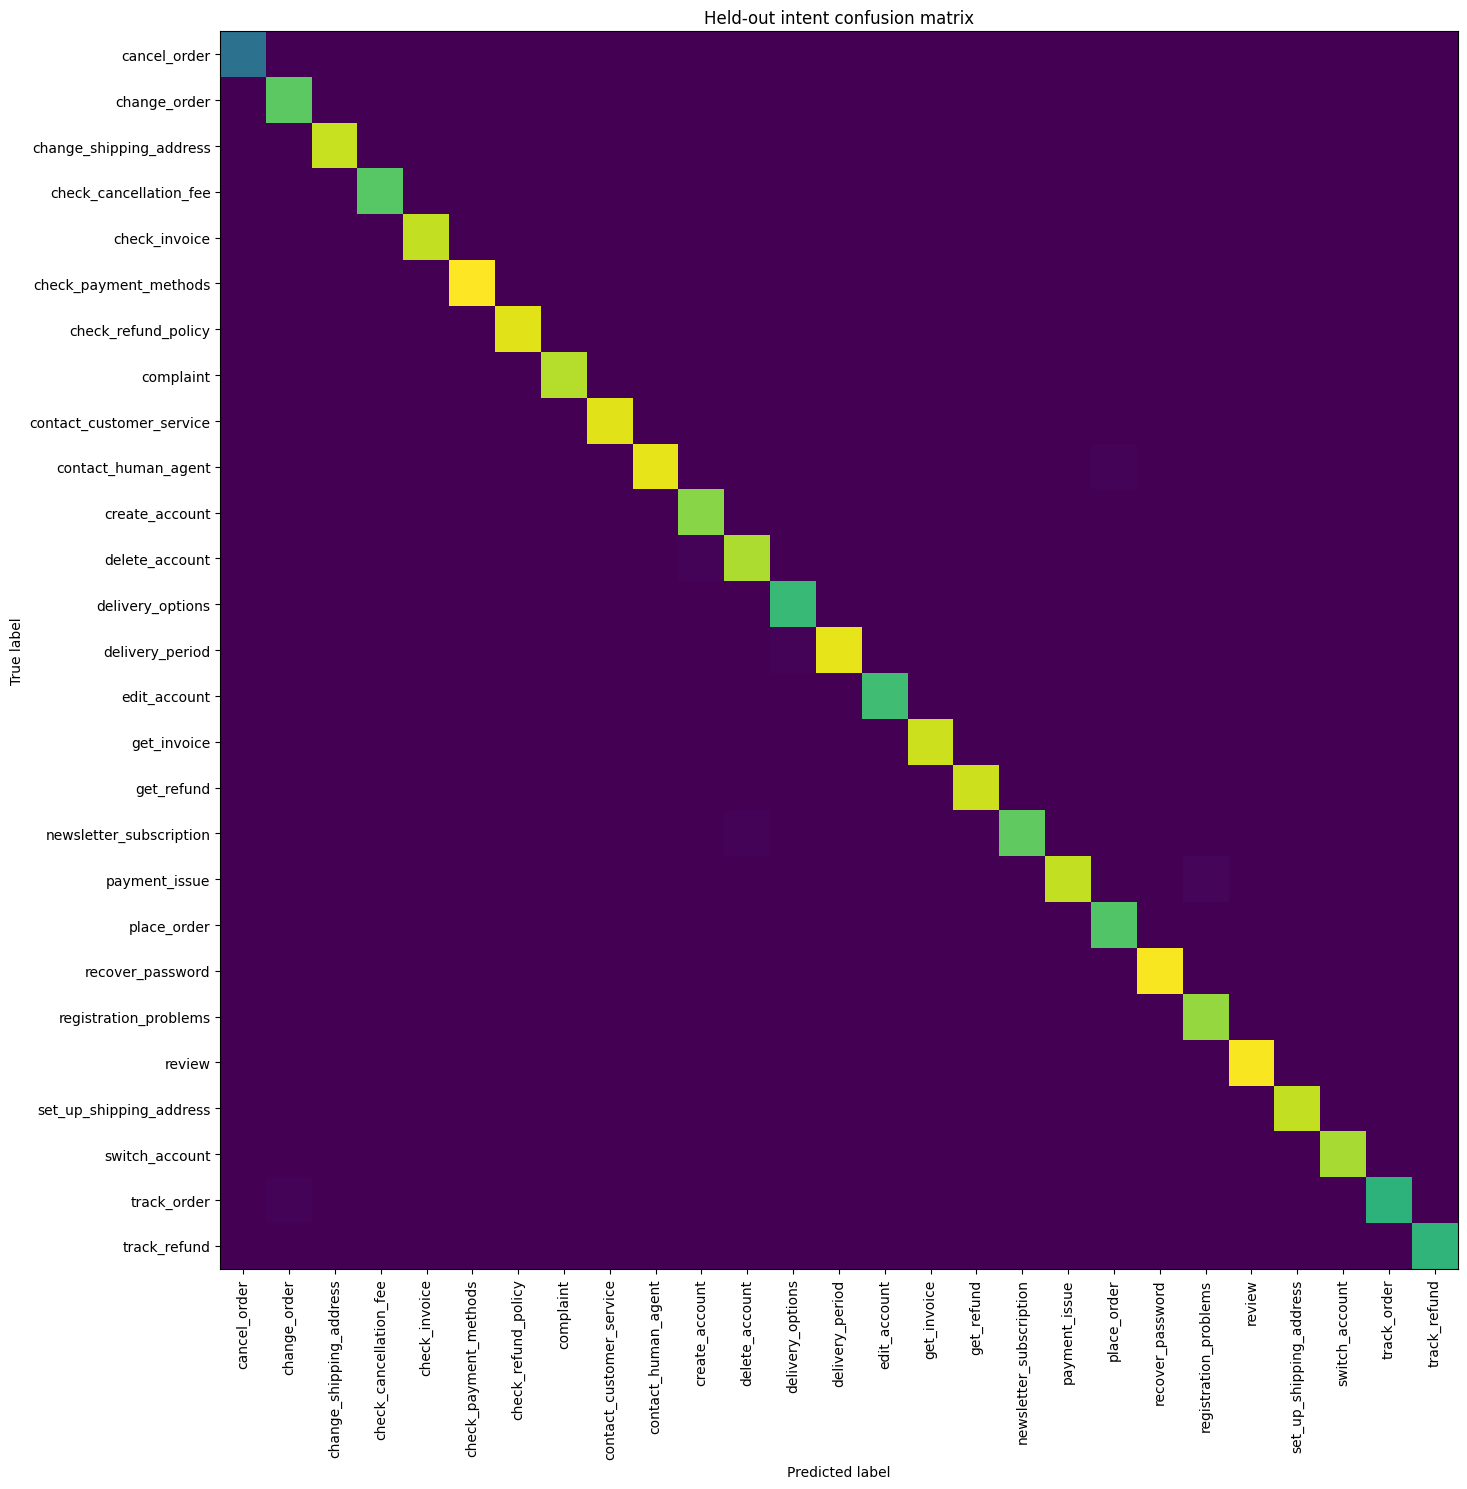

In [6]:
test_pred, test_margin, test_features = score_batch(best_pipeline,test.instruction)
accepted = np.zeros(len(test),dtype=bool) if REVIEW_ALL else test_features & (test_margin >= MARGIN_THRESHOLD)
test_metrics = {'accuracy':accuracy_score(test.intent,test_pred),
                'macro_f1':f1_score(test.intent,test_pred,labels=LABELS,average='macro',zero_division=0),
                'route_accuracy':accuracy_score(test.intent.map(ROUTES),pd.Series(test_pred).map(ROUTES)),
                'test_examples':len(test), 'accepted_examples':int(accepted.sum()),
                'coverage':float(accepted.mean()),
                'accepted_accuracy':float(accuracy_score(test.intent.to_numpy()[accepted],test_pred[accepted])) if accepted.any() else None}
print(json.dumps(test_metrics,indent=2))
(REPORTS / 'test_metrics.json').write_text(json.dumps(test_metrics,indent=2))
report = pd.DataFrame(classification_report(test.intent,test_pred,labels=LABELS,output_dict=True,zero_division=0)).T
report.to_csv(REPORTS / 'classification_report.csv')
display(report)
predictions = test[['instruction','intent']].rename(columns={'intent':'actual'}).copy()
predictions['predicted'] = test_pred
predictions['margin'] = test_margin
predictions['needs_review'] = ~accepted
predictions.to_csv(REPORTS / 'test_predictions.csv',index=False)
display(predictions[predictions.actual != predictions.predicted].head(20))
fig,ax = plt.subplots(figsize=(15,15))
ConfusionMatrixDisplay.from_predictions(test.intent,test_pred,labels=LABELS,ax=ax,xticks_rotation=90,include_values=False,colorbar=False)
ax.set_title('Held-out intent confusion matrix')
fig.tight_layout(); fig.savefig(REPORTS / 'confusion_matrix.png',dpi=150); plt.show()


## 7. Save a portable model and prediction module
The saved pipeline uses only built-in scikit-learn objects; no notebook-defined function is pickled. The separate Python module adds routing, input checks and conservative rules for standalone social phrases. “Hi, where is my order?” still goes to the classifier.

`needs_clarification` is a fallback, not a 28th trained intent or proof of out-of-scope content. Multi-intent messages, explicit-human-request combinations and ambiguous requests require further testing. English only; translation belongs to later integration. The model never retrieves private order status or performs actions.


In [7]:
EXPORT = RUN / 'export'
MODEL_DIR = EXPORT / 'model'
MODEL_DIR.mkdir(parents=True,exist_ok=True)
metadata = {'status':'trained_and_evaluated', 'selected_model':SELECTED_MODEL, 'seed':SEED,
            'routes':ROUTES, 'margin_threshold':MARGIN_THRESHOLD, 'review_all':REVIEW_ALL,
            'validation_results':rows,'test_metrics':test_metrics,'dataset_audit':audit,
            'versions':{p:version(p) for p in ['scikit-learn','numpy','pandas','joblib']},
            'limitations':['English only','27 supported training intents','No trained out-of-scope class',
                           'Margins are not probabilities','Template/paraphrase overlap may remain',
                           'Simple standalone social rules','Multi-intent handling is not guaranteed']}
(MODEL_DIR / 'metadata.json').write_text(json.dumps(metadata,indent=2))
joblib.dump(best_pipeline,MODEL_DIR / 'pipeline.joblib')
MODULE_SOURCE = '"""Load a trusted classical intent export and predict English customer intents."""\nfrom pathlib import Path\nimport json\nimport re\nimport joblib\nimport numpy as np\n\nclass IntentDetector:\n    def __init__(self, model_dir=None):\n        directory = Path(model_dir) if model_dir else Path(__file__).resolve().parent / \'model\'\n        self.metadata = json.loads((directory / \'metadata.json\').read_text())\n        self.pipeline = joblib.load(directory / \'pipeline.joblib\')\n        self.routes = self.metadata[\'routes\']\n        if set(self.pipeline.classes_) != set(self.routes):\n            raise ValueError(\'Pipeline labels do not match routing metadata.\')\n\n    def predict(self, text, language=\'en\'):\n        if language != \'en\':\n            raise ValueError(\'Translate the message into English first.\')\n        if not isinstance(text,str) or not text.strip() or len(text)>10000:\n            raise ValueError(\'Use a nonempty string of at most 10,000 characters.\')\n        social = re.sub(r\'[^\\w\\s]\', \'\', text.casefold()).strip()\n        social = \' \'.join(social.split())\n        for label, phrases in {\n            \'greeting\': {\'hi\',\'hello\',\'hey\',\'good morning\',\'good evening\'},\n            \'goodbye\': {\'bye\',\'goodbye\',\'see you\',\'bye for now\'},\n            \'gratitude\': {\'thanks\',\'thank you\',\'thanks a lot\',\'thank you very much\'},\n        }.items():\n            if social in phrases:\n                return {\'intent\':label,\'candidate_intent\':None,\'route\':label,\'margin\':None,\n                        \'needs_review\':False,\'priority\':False,\'reason\':\'standalone_social_rule\'}\n        matrix = self.pipeline.named_steps[\'tfidf\'].transform([text])\n        if matrix.nnz == 0:\n            return {\'intent\':\'needs_clarification\',\'candidate_intent\':None,\n                    \'route\':\'needs_clarification\',\'margin\':None,\'needs_review\':True,\n                    \'priority\':False,\'reason\':\'no_known_features\'}\n        clf = self.pipeline.named_steps[\'classifier\']\n        scores = clf.decision_function(matrix)[0]\n        candidate = str(clf.classes_[scores.argmax()])\n        ordered = np.sort(scores)\n        margin = float(ordered[-1]-ordered[-2])\n        review = self.metadata[\'review_all\'] or margin < self.metadata[\'margin_threshold\']\n        label = \'needs_clarification\' if review else candidate\n        return {\'intent\':label,\'candidate_intent\':candidate,\n                \'route\':\'needs_clarification\' if review else self.routes[candidate],\n                \'margin\':margin,\'needs_review\':bool(review),\n                \'priority\':self.routes[candidate] in {\'complaint\',\'human_handoff\'},\n                \'reason\':\'uncertain_prediction\' if review else \'model_prediction\'}\n\nif __name__ == \'__main__\':\n    import argparse\n    parser = argparse.ArgumentParser()\n    parser.add_argument(\'message\')\n    args = parser.parse_args()\n    print(json.dumps(IntentDetector().predict(args.message),indent=2))\n'
(EXPORT / 'intent_detection.py').write_text(MODULE_SOURCE)
(EXPORT / 'requirements.txt').write_text('\n'.join(f"{p}=={version(p)}" for p in ['scikit-learn','numpy','joblib'])+'\n')
reloaded = joblib.load(MODEL_DIR / 'pipeline.joblib')
np.testing.assert_array_equal(reloaded.predict(test.instruction),test_pred)
print('Reload check passed on every test prediction.')
# Import the actual exported module, not an alternate notebook implementation.
import importlib.util
spec = importlib.util.spec_from_file_location('exported_intent',EXPORT / 'intent_detection.py')
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)
detector = module.IntentDetector(MODEL_DIR)


Reload check passed on every test prediction.


## 8. Qualitative behavior checks
These examples are author-written checks, not independent benchmark data. Inspect the output: unsupported messages may still get a supported intent. Do not present the rules or review threshold as a reliable out-of-scope classifier. Do not assume emotion changes intent.

For a stronger later evaluation, collect new independently labeled customer messages before seeing predictions.


In [8]:
examples = [
    ('Hello!', 'greeting'),
    ('Thank you!', 'gratitude'),
    ('Bye for now.', 'goodbye'),
    ('Hi, where is my order?', 'track_order'),
    ('I am furious. Where is my order?', 'track_order'),
    ('Please cancel my purchase.', 'cancel_order'),
    ('Can you check whether my refund has arrived?', 'track_refund'),
    ('I forgot my password.', 'recover_password'),
    ('Please connect me to a human.', 'contact_human_agent'),
    ('wher is my pakage', 'track_order'),
    ('Give me a chocolate cake recipe.', 'out_of_scope (desired; not trained)'),
    ('Cancel my order and delete my account.', 'multiple requests; needs clarification desired'),
]
behavior = pd.DataFrame([{'text':text,'expected_behavior':expected,**detector.predict(text)} for text,expected in examples])
behavior.to_csv(REPORTS / 'behavior_checks.csv',index=False)
with pd.option_context('display.max_colwidth',100):
    display(behavior)
for invalid in ['', '   ']:
    try:
        detector.predict(invalid)
    except ValueError:
        pass
    else:
        raise AssertionError('Blank input was accepted.')
print('Blank-input checks passed.')


,text,expected_behavior,intent,candidate_intent,route,margin,needs_review,priority,reason
0,Hello!,greeting,greeting,None,greeting,NaN,False,False,standalone_social_rule
1,Thank you!,gratitude,gratitude,None,gratitude,NaN,False,False,standalone_social_rule
2,Bye for now.,goodbye,goodbye,None,goodbye,NaN,False,False,standalone_social_rule
3,"Hi, where is my order?",track_order,track_order,track_order,order_status,0.079152,False,False,model_prediction
4,I am furious. Where is my order?,track_order,track_order,track_order,order_status,0.076727,False,False,model_prediction
5,Please cancel my purchase.,cancel_order,cancel_order,cancel_order,order_management,0.477778,False,False,model_prediction
6,Can you check whether my refund has arrived?,track_refund,track_refund,track_refund,billing_and_refunds,1.031573,False,False,model_prediction
7,I forgot my password.,recover_password,recover_password,recover_password,account_management,1.611195,False,False,model_prediction
8,Please connect me to a human.,contact_human_agent,contact_human_agent,contact_human_agent,human_handoff,0.698117,False,True,model_prediction
9,wher is my pakage,track_order,delivery_period,delivery_period,order_status,0.201964,False,False,model_prediction


Blank-input checks passed.


## 9. Export and next step
The ZIP includes the fitted vectorizer/classifier, portable prediction module, package versions, routing rules, splits and evaluation reports. Keep it with the notebook saved **with outputs**. There is no API key.

Load joblib files only from trusted sources. When moving to another environment, match the recorded library versions. The export's `intent_detection.py` defaults to the adjacent `model` folder.

Write your conclusion using actual results: winning model, validation/test macro-F1, per-intent errors, accepted accuracy and coverage, and limits. Do not claim that dataset accuracy equals real-world customer-support accuracy. Bring the executed notebook and ZIP back for review before integration.


In [9]:
shutil.copytree(REPORTS,EXPORT / 'reports',dirs_exist_ok=True)
(EXPORT / 'README.txt').write_text(
    'Classical English intent classifier. No Groq key or GPU needed.\n'
    'Install requirements.txt in a compatible Python environment.\n'
    'Run: python intent_detection.py "Where is my order?"\n'
    'Review model/metadata.json and reports before interpreting performance.\n'
    'Load only trusted joblib files.\n')
manifest = {str(p.relative_to(EXPORT)):hashlib.sha256(p.read_bytes()).hexdigest()
            for p in EXPORT.rglob('*') if p.is_file() and p.name != 'manifest.json' and '__pycache__' not in p.parts}
# Remove import bytecode from the portable bundle.
for cache in EXPORT.rglob('__pycache__'):
    shutil.rmtree(cache)
(EXPORT / 'manifest.json').write_text(json.dumps(manifest,indent=2))
archive = shutil.make_archive(str(RUN / 'intent_classifier_export'),'zip',EXPORT)
print('Export ready:',archive)
print('Save this notebook with outputs as well.')
if 'google.colab' in sys.modules:
    from google.colab import files
    files.download(archive)


Export ready: /content/intent_classical_work/runs/20260903-095023-687516/intent_classifier_export.zip
Save this notebook with outputs as well.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## References
- Bitext dataset: https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset
- TF-IDF: https://scikit-learn.org/1.6/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
- Pipelines and leakage: https://scikit-learn.org/1.6/common_pitfalls.html
- Grouped stratification: https://scikit-learn.org/1.6/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html
- Linear SVM: https://scikit-learn.org/1.6/modules/generated/sklearn.svm.LinearSVC.html
